# Chapter 3 - Deep Q-learning
### Deep Reinforcement Learning *in Action*

In [1]:
import os
import random

import numpy as np
import torch
from matplotlib import pylab as plt

if not os.path.isdir("Environments"):
    os.chdir("..")

from Environments.Gridworld import Gridworld

action_set = {
    0: "u",
    1: "d",
    2: "l",
    3: "r",
}

##### Listing 3.1 - Creating a Gridworld game

In [2]:
game = Gridworld(size=4, mode="static")
game.display()

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [3]:
game.makeMove("d")
game.makeMove("d")
reward, done = game.makeMove("l")
game.display()

array([['+', '-', ' ', ' '],
       [' ', 'W', ' ', ' '],
       [' ', ' ', 'P', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [4]:
reward

-1

In [5]:
state = game.board.render_np()
print(state.shape)
state

(4, 4, 4)


array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

##### Listing 3.2 - Neural network Q function

In [6]:
l1 = 64
l2 = 128
l3 = 128
l4 = 4

learning_rate = 1e-3
gamma = 0.9
epsilon = 1.0

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.ReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.ReLU(),
    torch.nn.Linear(l3, l4),
)
loss_fn = torch.nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

##### Listing 3.3 - Q-learning: Main training loop

In [7]:
epochs = 1000
wins = 0
pits = 0

losses = []  # A
for i in range(epochs):  # B
    game = Gridworld(size=4, mode="static")  # C
    state_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0  # D
    state1 = torch.from_numpy(state_).float()  # E
    status = 1  # F
    while status == 1:  # G
        qval = model(state1)[0]  # H
        if random.random() < epsilon:  # I
            action_ = np.random.randint(0, 4)
        else:
            qval_ = qval.data.numpy()
            action_ = np.argmax(qval_)

        action = action_set[action_]  # J
        reward, done = game.makeMove(action)  # K
        state_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
        state2 = torch.from_numpy(state_).float()  # L
        with torch.no_grad():
            newQ = model(state2)[0]
        maxQ = torch.max(newQ)  # M
        if done:  # N
            Y = reward
        else:
            Y = reward + (gamma * maxQ)
        Y = torch.Tensor([Y]).detach().squeeze()
        X = qval.squeeze()[action_]  # O
        loss = loss_fn(X, Y)  # P

        optimizer.zero_grad()
        loss.backward()
        losses.append(loss.item())
        optimizer.step()

        state1 = state2
        if done:  # Q
            if reward == 10:
                wins += 1
            elif reward == -10:
                pits += 1
            status = 0
    if epsilon > 0.1:  # R
        epsilon -= 1 / epochs

print(f"Number of wins: {wins}")
print(f"Number of pits: {pits}")

Number of wins: 807
Number of pits: 193


Text(0, 0.5, 'Loss')

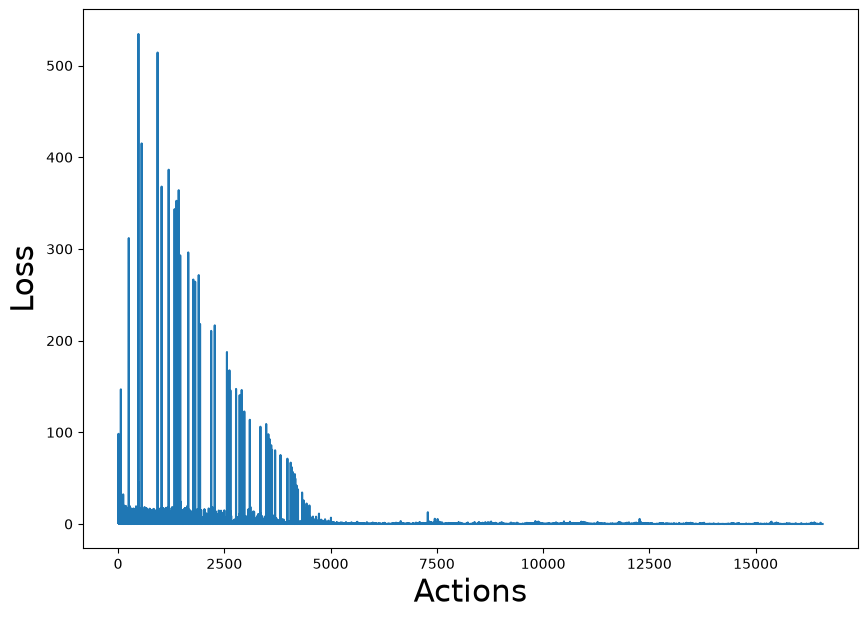

In [8]:
plt.figure(figsize=(10, 7))
plt.plot(losses)
plt.xlabel("Actions", fontsize=22)
plt.ylabel("Loss", fontsize=22)

##### PyTorch Automatic Differentiation Review

In [9]:
m = torch.Tensor([2.0])
m.requires_grad = True
b = torch.Tensor([1.0])
b.requires_grad = True


def linear_model(x, m, b):
    y = m @ x + b  # m @ x + b
    return y

In [10]:
# with torch.no_grad():
y = linear_model(torch.Tensor([4]), m, b)
print(y)
print(y.grad_fn)
y.backward()

tensor([9.], grad_fn=<AddBackward0>)


In [11]:
print(m.grad)
print(b.grad)

tensor([4.])
tensor([1.])


##### Listing 3.4 - Testing the Q-network

In [12]:
def test_model(model, mode="static", display=True):
    i = 0
    test_game = Gridworld(mode=mode)
    state_ = test_game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
    state = torch.from_numpy(state_).float()
    if display:
        print("Initial State:")
        print(test_game.display())
    status = 1
    while status == 1:  # A
        qval = model(state)
        qval_ = qval.data.numpy()
        action_ = np.argmax(qval_)  # B
        action = action_set[action_]
        if display:
            print("Move #: %s; Taking action: %s" % (i, action))
        reward, done = test_game.makeMove(action)
        state_ = (
            test_game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
        )
        state = torch.from_numpy(state_).float()
        if display:
            print(test_game.display())
        if done:
            if reward > 0:
                status = 2
                if display:
                    print("Game won! Reward: %s" % (reward,))
            else:
                status = 0
                if display:
                    print("Game LOST. Reward: %s" % (reward,))
        i += 1
        if i > 15:
            if display:
                print("Game lost; too many moves.")
            break

    win = True if status == 2 else False
    return win

In [13]:
test_model(model, "static")

Initial State:
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 0; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' 'P']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 1; Taking action: l
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 2; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 3; Taking action: l
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' 'P' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 4; Taking action: l
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 ['P' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 5; Taking action: u
[['+' '-' ' ' ' ']
 ['P' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 6; Taking action: u
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Game won! Reward: 10


True

In [14]:
test_model(model, "random")

Initial State:
[[' ' ' ' ' ' 'P']
 ['-' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 ['+' ' ' ' ' 'W']]
Move #: 0; Taking action: d
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' 'P']
 [' ' ' ' ' ' ' ']
 ['+' ' ' ' ' 'W']]
Move #: 1; Taking action: d
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' ' ']
 [' ' ' ' ' ' 'P']
 ['+' ' ' ' ' 'W']]
Move #: 2; Taking action: l
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' ' ']
 [' ' ' ' 'P' ' ']
 ['+' ' ' ' ' 'W']]
Move #: 3; Taking action: l
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' ' ']
 [' ' 'P' ' ' ' ']
 ['+' ' ' ' ' 'W']]
Move #: 4; Taking action: l
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' ' ']
 ['P' ' ' ' ' ' ']
 ['+' ' ' ' ' 'W']]
Move #: 5; Taking action: u
[[' ' ' ' ' ' ' ']
 ['-' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 ['+' ' ' ' ' 'W']]
Game LOST. Reward: -10


False

##### Listing 3.5 - DQN with experience replay

In [15]:
l1 = 64
l2 = 128
l3 = 128
l4 = 4

learning_rate = 1e-3
gamma = 0.9
epsilon = 0.1

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.ReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.ReLU(),
    torch.nn.Linear(l3, l4),
)
loss_fn = torch.nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
from collections import deque

epochs = 5000
losses = []
mem_size = 1000  # A
batch_size = 200  # B
replay = deque(maxlen=mem_size)  # C
max_moves = 50  # D
h = 0
for i in range(epochs):
    game = Gridworld(size=4, mode="random")
    state1_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
    state1 = torch.from_numpy(state1_).float()
    status = 1
    mov = 0
    while status == 1:
        mov += 1
        qval = model(state1)  # E
        if random.random() < epsilon:  # F
            action_ = np.random.randint(0, 4)
        else:
            qval_ = qval.data.cpu().numpy()
            action_ = np.argmax(qval_)

        action = action_set[action_]
        reward, done = game.makeMove(action)
        if done:
            status, mov = 0, 0
        elif mov > max_moves:  # O
            done, status, mov = 1, 0, 0
        state2_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
        state2 = torch.from_numpy(state2_).float()
        exp = (state1, action_, reward, state2, done)  # G
        replay.append(exp)  # H
        state1 = state2

        if len(replay) > batch_size:  # I
            minibatch = random.sample(replay, batch_size)  # J
            state1_batch = torch.cat([s1 for (s1, a, r, s2, d) in minibatch])  # K
            action_batch = torch.tensor([a for (s1, a, r, s2, d) in minibatch])
            reward_batch = torch.tensor([r for (s1, a, r, s2, d) in minibatch])
            state2_batch = torch.cat([s2 for (s1, a, r, s2, d) in minibatch])
            done_batch = torch.tensor([d for (s1, a, r, s2, d) in minibatch])

            Q1 = model(state1_batch)  # L
            with torch.no_grad():
                Q2 = model(state2_batch)  # M

            Y = reward_batch + gamma * ((1 - done_batch) * torch.max(Q2, dim=1)[0])  # N
            X = Q1.gather(dim=1, index=action_batch.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            optimizer.zero_grad()
            loss.backward()
            losses.append(loss.item())
            optimizer.step()

losses = np.array(losses)

# A Set the total size of the experience replay memory
# B Set the minibatch size
# C Create the memory replay as a deque list
# D Maximum number of moves before game is over
# E Compute Q-values from input state in order to select action
# F Select action using epsilon-greedy strategy
# G Create experience of state, reward, action and next state as a tuple
# H Add experience to experience replay list
# I If replay list is at least as long as minibatch size, begin minibatch training
# J Randomly sample a subset of the replay list
# K Separate out the components of each experience into separate minibatch tensors
# L Re-compute Q-values for minibatch of states to get gradients
# M Compute Q-values for minibatch of next states but don't compute gradients
# N Compute the target Q-values we want the DQN to learn
# O If game is over, reset status and mov number

Text(0, 0.5, 'Loss')

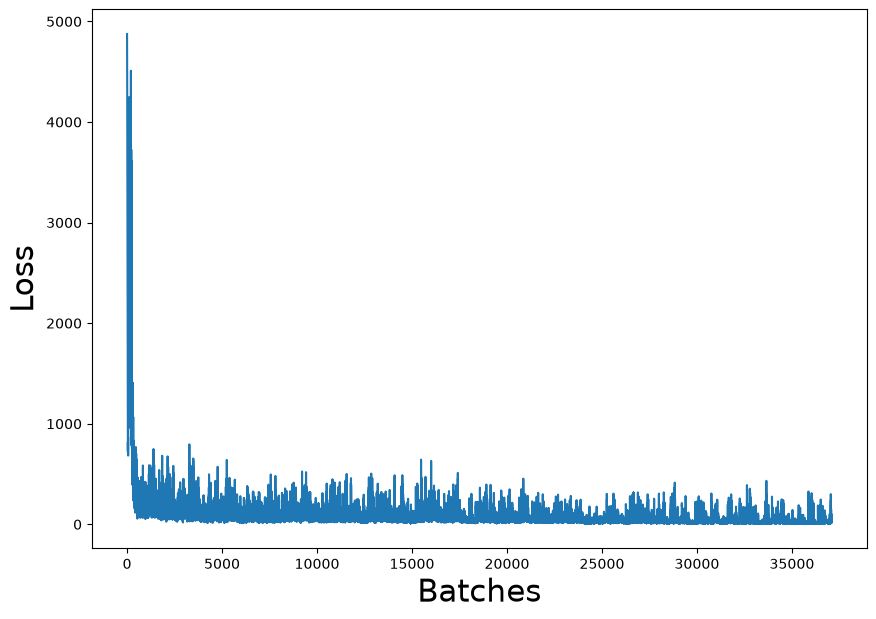

In [17]:
plt.figure(figsize=(10, 7))
plt.plot(losses)
plt.xlabel("Batches", fontsize=22)
plt.ylabel("Loss", fontsize=22)

In [18]:
def running_mean(x, N=50):
    c = x.shape[0] - N
    y = np.zeros(c)
    conv = np.ones(N)
    for i in range(c):
        y[i] = (x[i : i + N] @ conv) / N
    return y

Text(0, 0.5, 'Running average loss')

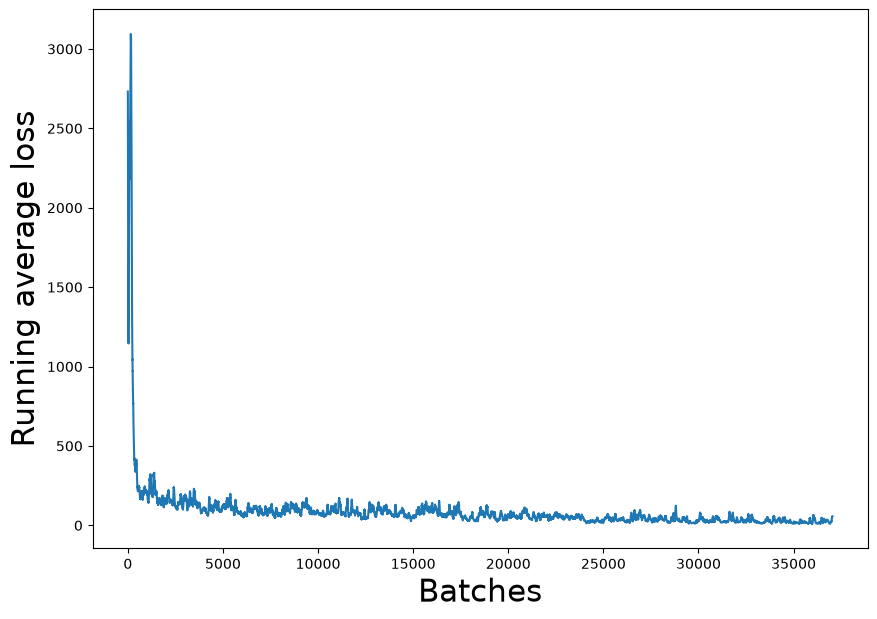

In [19]:
plt.figure(figsize=(10, 7))
plt.plot(running_mean(losses))
plt.xlabel("Batches", fontsize=22)
plt.ylabel("Running average loss", fontsize=22)

##### Listing 3.6 - Testing the performance with experience replay

In [20]:
max_games = 1000
wins = 0
for i in range(max_games):
    win = test_model(model, mode="random", display=False)
    if win:
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games, wins))
print("Win percentage: {}%".format(100.0 * win_perc))

Games played: 1000, # of wins: 906
Win percentage: 90.60000000000001%


In [21]:
test_model(model, mode="static")

Initial State:
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 0; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' 'P']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 1; Taking action: l
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 2; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 3; Taking action: u
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 4; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 5; Taking action: u
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 6; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 7; Taking action: u
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 8; Taking action: d
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [

False

##### Listing 3.7 - Target network

In [22]:
import copy

l1 = 64
l2 = 128
l3 = 128
l4 = 4

learning_rate = 1e-3
gamma = 0.9
epsilon = 0.1

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.ReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.ReLU(),
    torch.nn.Linear(l3, l4),
)
loss_fn = torch.nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

model2 = copy.deepcopy(model)  # A
model2.load_state_dict(model.state_dict())  # B

<All keys matched successfully>

In [23]:
from collections import deque

epochs = 5000
losses = []
mem_size = 1000
batch_size = 200
replay = deque(maxlen=mem_size)
max_moves = 50
h = 0
sync_freq = 50  # A
j = 0
for i in range(epochs):
    game = Gridworld(size=4, mode="random")
    state1_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
    state1 = torch.from_numpy(state1_).float()
    status = 1
    mov = 0
    while status == 1:
        j += 1
        mov += 1
        qval = model(state1)
        if random.random() < epsilon:
            action_ = np.random.randint(0, 4)
        else:
            qval_ = qval.data.numpy()
            action_ = np.argmax(qval_)

        action = action_set[action_]
        reward, done = game.makeMove(action)
        if done:
            status, mov = 0, 0
        elif mov > max_moves:
            done, status, mov = 1, 0, 0
        state2_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
        state2 = torch.from_numpy(state2_).float()
        exp = (state1, action_, reward, state2, done)
        replay.append(exp)
        state1 = state2

        if len(replay) > batch_size:
            minibatch = random.sample(replay, batch_size)
            state1_batch = torch.cat([s1 for (s1, a, r, s2, d) in minibatch])
            action_batch = torch.Tensor([a for (s1, a, r, s2, d) in minibatch])
            reward_batch = torch.Tensor([r for (s1, a, r, s2, d) in minibatch])
            state2_batch = torch.cat([s2 for (s1, a, r, s2, d) in minibatch])
            done_batch = torch.Tensor([d for (s1, a, r, s2, d) in minibatch])
            Q1 = model(state1_batch)
            with torch.no_grad():
                Q2 = model2(state2_batch)  # B

            Y = reward_batch + gamma * ((1 - done_batch) * torch.max(Q2, dim=1)[0])
            X = Q1.gather(dim=1, index=action_batch.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            optimizer.zero_grad()
            loss.backward()
            losses.append(loss.item())
            optimizer.step()

    if i % sync_freq == 0:  # C
        model2.load_state_dict(model.state_dict())

losses = np.array(losses)

# A Set the update frequency for synchronizing the target model parameters to the main DQN
# B Use the target network to get the maiximum Q-value for the next state
# C Copy the main model parameters to the target network

Text(0, 0.5, 'Loss')

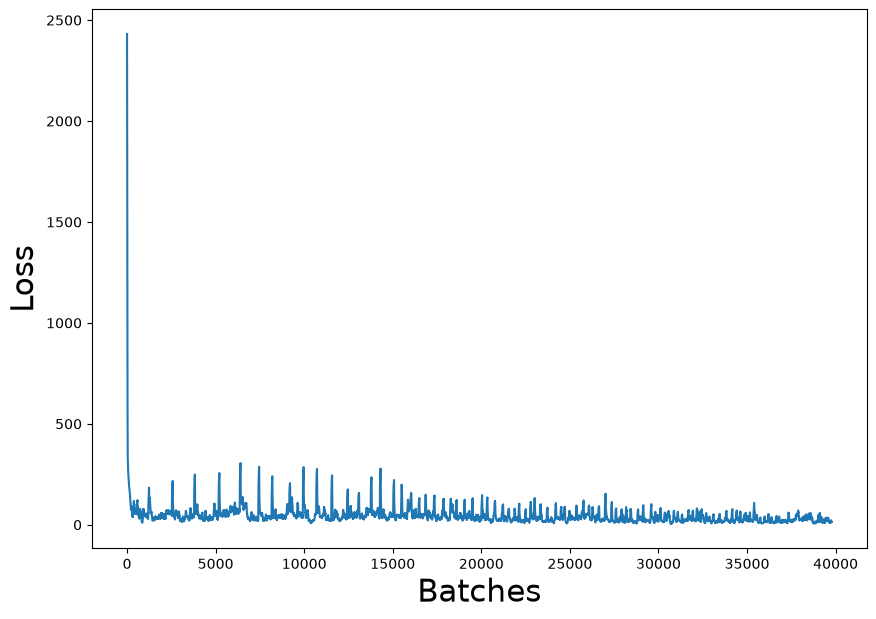

In [24]:
plt.figure(figsize=(10, 7))
plt.plot(running_mean(losses))
plt.xlabel("Batches", fontsize=22)
plt.ylabel("Loss", fontsize=22)

In [25]:
max_games = 1000
wins = 0
for i in range(max_games):
    win = test_model(model, mode="random", display=False)
    if win:
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games, wins))
print("Win percentage: {}%".format(100.0 * win_perc))

Games played: 1000, # of wins: 911
Win percentage: 91.10000000000001%


In [26]:
test_model(model, mode="static")

Initial State:
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 0; Taking action: l
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 1; Taking action: r
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 2; Taking action: l
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 3; Taking action: r
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 4; Taking action: l
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 5; Taking action: r
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 6; Taking action: l
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 7; Taking action: r
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 8; Taking action: l
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [

False